In [1]:
import nltk
import gensim
import pandas as pd
import matplotlib.pyplot as plt

##### import data

In [2]:
df = pd.read_csv('../data/news_articles.csv')
df.head()

,id,title,content
0,25626,"One Weight-Loss Approach Fits All? No, Not Eve...","Dr. Frank Sacks, a professor of nutrition at H..."
1,19551,South Carolina Stuns Baylor to Reach the Round...,South Carolina’s win over Duke was not only ...
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Yo...",(Want to get this briefing by email? Here’s th...
3,18026,"His Predecessor Gone, Gambia’s New President F...","BANJUL, Gambia — A week after he was inaugu..."
4,21063,‘Harry Potter and the Cursed Child’ Goes From ...,The biggest book of the summer isn’t a blockbu...


In [3]:
articles = df['content']

##### preprocess

In [4]:
articles = articles.str.lower()
articles.head(2)

0    dr. frank sacks, a professor of nutrition at h...
1    south carolina’s win over   duke was not only ...
Name: content, dtype: str

In [5]:
import re

articles = articles.apply(lambda article: re.sub(r'[^\w\s]', '', article))
articles.head(2)

0    dr frank sacks a professor of nutrition at har...
1    south carolinas win over   duke was not only a...
Name: content, dtype: str

In [6]:
from nltk import word_tokenize
nltk.download('punkt')

articles = articles.apply(lambda article: word_tokenize(article))
articles.head(2)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


0    [dr, frank, sacks, a, professor, of, nutrition...
1    [south, carolinas, win, over, duke, was, not, ...
Name: content, dtype: object

In [7]:
from nltk.corpus import stopwords
nltk.download('stopwords')

en_stopwords = stopwords.words('english')

articles = articles.apply(lambda article: [token for token in article if token not in en_stopwords])
articles.head(2)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    [dr, frank, sacks, professor, nutrition, harva...
1    [south, carolinas, win, duke, surprise, fans, ...
Name: content, dtype: object

In [8]:
from nltk import PorterStemmer
ps = PorterStemmer()

articles = articles.apply(lambda article: [ps.stem(token) for token in article])
articles.head(2)

0    [dr, frank, sack, professor, nutrit, harvard, ...
1    [south, carolina, win, duke, surpris, fan, pos...
Name: content, dtype: object

##### transform corpus

In [9]:
id2word = gensim.corpora.Dictionary(articles) # dictionary of {token_id: token}
print(id2word)

Dictionary<8691 unique tokens: ['10', '100', '108', '15', '155']...>


In [10]:
# no_below: keep tokens that appear in atleast 'n' docs
# no_above: remove tokens that appear in more than 'k %' of docs

id2word.filter_extremes(no_below = 5, no_above = 0.3)
print(id2word)

Dictionary<1767 unique tokens: ['10', '100', '15', '1970', '20']...>


bag of words

In [11]:
bow = [id2word.doc2bow(article) for article in articles] # convert to list of lists where each list is a list of (word_id, freq)

In [12]:
[list[:6] for list in bow[:2]]

[[(0, 1), (1, 1), (2, 2), (3, 1), (4, 1), (5, 1)],
 [(4, 2), (14, 1), (20, 1), (35, 2), (46, 1), (47, 1)]]

TF-IDF

In [13]:
tfidf_model = gensim.models.TfidfModel(bow) # learn idf weights from bow

tfidf = tfidf_model[bow] # apply tf-idf on bow

In [14]:
[list[:2] for list in tfidf[:2]]

[[(0, np.float64(0.009301553577602251)),
  (1, np.float64(0.015189632197218347))],
 [(4, np.float64(0.06841738304388505)), (14, np.float64(0.03758760457901894))]]

##### Latent Dirichlet Allocation

> the intuition
- each document is a mixture of topics
- each topic is a mixture of words

In [15]:
lda = gensim.models.LdaModel(corpus = bow, id2word = id2word, num_topics = 3)

In [16]:
lda.print_topics(num_topics = 3, num_words = 6)

[(0,
  '0.004*"dr" + 0.003*"percent" + 0.003*"school" + 0.002*"execut" + 0.002*"islam" + 0.002*"immigr"'),
 (1,
  '0.004*"republican" + 0.003*"vote" + 0.003*"polic" + 0.003*"deal" + 0.003*"stori" + 0.003*"democrat"'),
 (2,
  '0.004*"polic" + 0.003*"fire" + 0.003*"rate" + 0.003*"account" + 0.003*"percent" + 0.003*"depart"')]

##### Latent Semantic Analysis

> the intuition
- words with similar meaning tend to appear in similar contexts
- it uses Singular Value Decomposition to uncover latent semantic structure

> LSA often gives better results with TF-IDF than BOW

In [17]:
lsa = gensim.models.LsiModel(corpus = tfidf, id2word = id2word, num_topics = 3)

In [18]:
lsa.print_topics(num_topics = 3, num_words = 6)

[(0,
  '0.102*"polic" + 0.085*"immigr" + 0.076*"republican" + 0.071*"vote" + 0.070*"speech" + 0.067*"song"'),
 (1,
  '0.301*"album" + 0.281*"song" + 0.209*"band" + 0.200*"music" + 0.124*"fan" + 0.113*"singer"'),
 (2,
  '0.462*"polic" + 0.186*"shot" + 0.168*"violenc" + 0.167*"shoot" + -0.159*"republican" + -0.158*"ryan"')]

##### Coherent Score

> used to find the optimal no. of topics

In [19]:
lda_scores = []
lsa_scores = []

max_topics = 10

for num_topics in range(2, max_topics + 1):
    lda = gensim.models.LdaModel(corpus = bow, id2word = id2word, num_topics = num_topics, random_state = 0)
    lsa = gensim.models.LsiModel(corpus = tfidf, id2word = id2word, num_topics = num_topics, random_seed = 0)

    lda_coherence = gensim.models.CoherenceModel(model = lda, texts = articles, dictionary = id2word, coherence = 'c_v')
    lsa_coherence = gensim.models.CoherenceModel(model = lsa, texts = articles, dictionary = id2word, coherence = 'c_v')

    lda_scores.append(lda_coherence.get_coherence())
    lsa_scores.append(lsa_coherence.get_coherence())

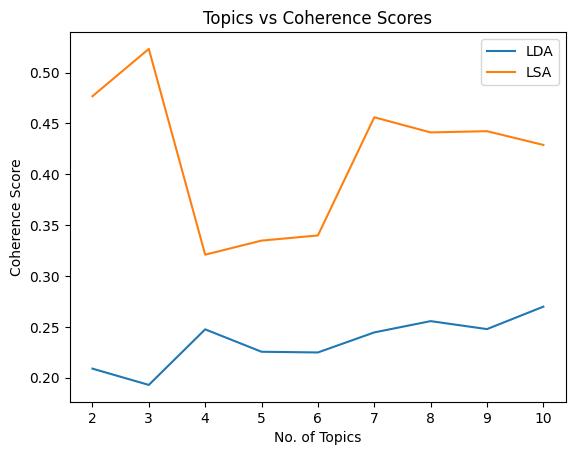

In [20]:
plt.plot(range(2, max_topics + 1), lda_scores, label = 'LDA')
plt.plot(range(2, max_topics + 1), lsa_scores, label = 'LSA')

plt.title('Topics vs Coherence Scores')
plt.xlabel('No. of Topics')
plt.ylabel('Coherence Score')
plt.legend()
plt.show()